# Practical 1: The Math of Neural Networks (NumPy Only)

---

### Objective
Implement the **Backpropagation algorithm from scratch** using only NumPy — no TensorFlow, no PyTorch — to deeply understand the calculus behind gradient updates.



---

## 1: Import Libraries



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")

Libraries loaded successfully!
NumPy version: 2.0.2


## 2: Prepare the XOR Dataset

### Why XOR?
The **XOR (Exclusive OR)** problem is a classic benchmark:
- A **single perceptron** (linear classifier) **cannot** solve XOR because XOR is not linearly separable.
- A **Multi-Layer Perceptron (MLP)** with at least one hidden layer **can** solve XOR.
- The XOR (Exclusive OR) problem is a fundamental mathematical challenge used to prove that a **single-layer neural network** (Perceptron) is insufficient, requiring a **multi-layer network** with **non-linear activation functions** to solve it

| Input A | Input B | Output (A XOR B) |
|---------|---------|------------------|
|    0    |    0    |        0         |
|    0    |    1    |        1         |
|    1    |    0    |        1         |
|    1    |    1    |        0         |

XOR Dataset:
------------------------------
  Input: [0 0] => Output: 0
  Input: [0 1] => Output: 1
  Input: [1 0] => Output: 1
  Input: [1 1] => Output: 0


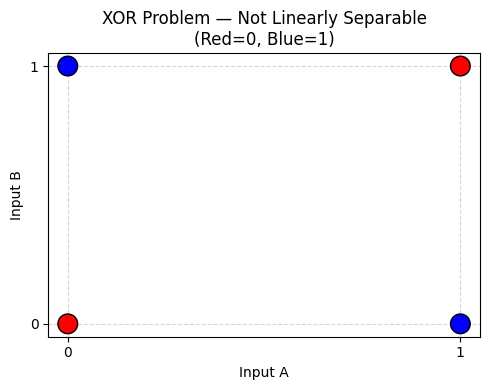

In [2]:
# XOR input: 4 samples, 2 features each
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])  # Shape: (4, 2)

# XOR output: expected labels
y = np.array([[0],
              [1],
              [1],
              [0]])  # Shape: (4, 1)

print("XOR Dataset:")
print("-" * 30)
for i in range(len(X)):
    print(f"  Input: {X[i]} => Output: {y[i][0]}")

# Visualize XOR data
plt.figure(figsize=(5, 4))
colors = ['red' if label == 0 else 'blue' for label in y.flatten()]
plt.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='black', zorder=5)
plt.title("XOR Problem — Not Linearly Separable\n(Red=0, Blue=1)")
plt.xlabel("Input A")
plt.ylabel("Input B")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##  3: Define Activation Functions

### Sigmoid Function
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Output range: **(0, 1)** — ideal for binary classification output
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — used in backpropagation
- The sigmoid function is a mathematical function with a characteristic "S"-shaped curve (sigmoid curve) that maps any real-valued number into a range between 0 and 1.
- It is primarily used in logistic regression for binary classification to predict probabilities and as an activation function in neural networks to introduce non-linearity

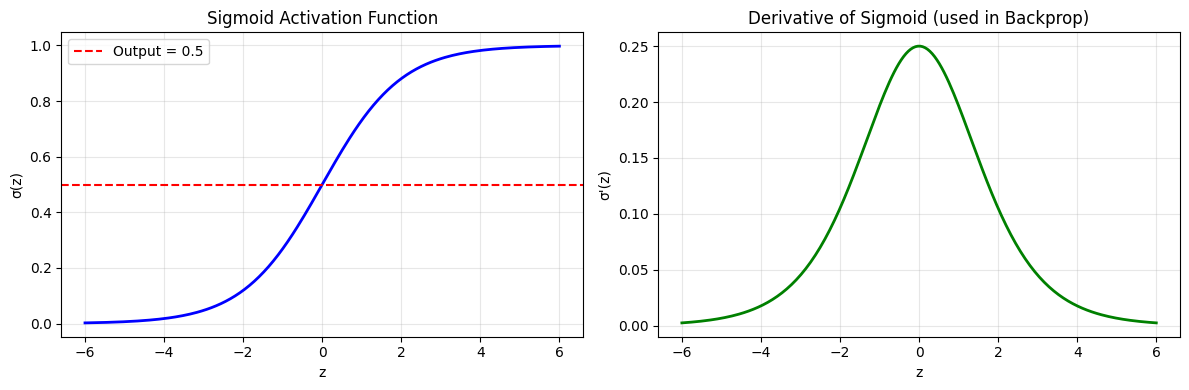

Note: The derivative is max at z=0 (~0.25) and near-zero at extremes → Vanishing Gradient problem!


In [14]:
def sigmoid(z):
    """sigmoid activation function
    σ(z)=1/1+e^−z
    Args:
        z: numpy array of pre-activation values
    Returns:
        Activated output in range (0, 1)
    """
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    """Derivative of Sigmoid — used during Backpropagation.

    Formula: sigmoid(z) * (1 - sigmoid(z))
    This tells us how much the output changes w.r.t. input z.
    """
    s = sigmoid(z)
    return s * (1 - s)


# Visualize the sigmoid function and its derivative
z_vals = np.linspace(-6, 6, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z_vals, sigmoid(z_vals), color='blue', linewidth=2)
axes[0].set_title("Sigmoid Activation Function")
axes[0].set_xlabel("z")
axes[0].set_ylabel("σ(z)")
axes[0].axhline(0.5, color='red', linestyle='--', label='Output = 0.5')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(z_vals, sigmoid_derivative(z_vals), color='green', linewidth=2)
axes[1].set_title("Derivative of Sigmoid (used in Backprop)")
axes[1].set_xlabel("z")
axes[1].set_ylabel("σ'(z)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Note: The derivative is max at z=0 (~0.25) and near-zero at extremes → Vanishing Gradient problem!")

##  4: Build the Neural Network Class

### Architecture for XOR
```
Input Layer → Hidden Layer → Output Layer
2 neurons       4 neurons        1 neuron
```

### Forward Propagation Formula
$$Z^{[l]} = W^{[l]} \cdot A^{[l-1]} + b^{[l]}$$
$$A^{[l]} = \sigma(Z^{[l]})$$

### Loss Function (Binary Cross-Entropy)
$$L = -\frac{1}{m}\sum [y \log(\hat{y}) + (1-y)\log(1-\hat{y})]$$

In [15]:
class NeuralNetwork:
    """
    A simple Multi-Layer Perceptron implemented from scratch using NumPy.
    Activation: Sigmoid at all layers
    Loss: Binary Cross-Entropy
    Optimizer: Vanilla Gradient Descent
    """

    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        """
        Initialize network weights and biases randomly.

        Args:
            input_size: Number of input features
            hidden_size: Number of neurons in hidden layer
            output_size: Number of output neurons
            learning_rate: Step size for gradient descent
        """
        self.lr = learning_rate
        self.loss_history = []  # Track loss over epochs

        # ------------------------------------------------------------------
        # Weight Initialization (Xavier/Glorot-inspired scaling)
        # Using small random values prevents symmetry breaking issues.
        # If all weights = 0, all neurons learn the same thing (symmetry problem).
        # ------------------------------------------------------------------
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5   # (2, 4)
        self.b1 = np.zeros((1, hidden_size))                         # (1, 4)

        self.W2 = np.random.randn(hidden_size, output_size) * 0.5   # (4, 1)
        self.b2 = np.zeros((1, output_size))                         # (1, 1)

        print(f"Network Initialized!")
        print(f"  W1 shape: {self.W1.shape}  (input→hidden)")
        print(f"  b1 shape: {self.b1.shape}")
        print(f"  W2 shape: {self.W2.shape}  (hidden→output)")
        print(f"  b2 shape: {self.b2.shape}")
        print(f"  Learning Rate: {self.lr}")

    def forward(self, X):
        """
        Forward Propagation: compute output from input.

        Steps:
          Layer 1: Z1 = X·W1 + b1  →  A1 = sigmoid(Z1)
          Layer 2: Z2 = A1·W2 + b2 →  A2 = sigmoid(Z2)  [final output]
        """
        # Hidden Layer computation
        self.Z1 = np.dot(X, self.W1) + self.b1   # Pre-activation: (4, 4)
        self.A1 = sigmoid(self.Z1)                # Post-activation: (4, 4)

        # Output Layer computation
        self.Z2 = np.dot(self.A1, self.W2) + self.b2  # Pre-activation: (4, 1)
        self.A2 = sigmoid(self.Z2)                      # Final output: (4, 1)

        return self.A2

    def compute_loss(self, y_true, y_pred):
        """
        Binary Cross-Entropy Loss.
        Measures how far predictions are from true labels.
        Lower loss = better predictions.
        """
        m = y_true.shape[0]  # Number of samples
        # Clip to avoid log(0) which is undefined
        y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

    def backward(self, X, y):
        """
        Backward Propagation: compute gradients using the Chain Rule.

        Chain Rule allows us to find how much each weight contributed to the loss.
        We then update weights in the opposite direction of the gradient.

        Gradients flow: Loss → Layer2 → Layer1
        """
        m = X.shape[0]  # batch size

        # ---- Output Layer Gradients ----
        # dL/dA2: derivative of loss w.r.t. output
        dA2 = self.A2 - y  # Simplified for binary cross-entropy + sigmoid combo

        # dL/dZ2 = dL/dA2 * sigmoid'(Z2)
        dZ2 = dA2 * sigmoid_derivative(self.Z2)

        # dL/dW2 = A1^T · dZ2
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # ---- Hidden Layer Gradients ----
        # Chain Rule: propagate error backwards through W2
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * sigmoid_derivative(self.Z1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ---- Update Weights (Gradient Descent) ----
        # W = W - lr * gradient  (move opposite to gradient = downhill)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=10000, print_every=1000):
        """
        Training loop: repeatedly do forward + backward passes.

        Args:
            X: Input features
            y: True labels
            epochs: Number of training iterations
            print_every: Print loss every N epochs
        """
        print(f"\nTraining for {epochs} epochs...")
        print("-" * 45)

        for epoch in range(epochs):
            # Step 1: Forward pass — compute predictions
            output = self.forward(X)

            # Step 2: Compute how wrong we are
            loss = self.compute_loss(y, output)
            self.loss_history.append(loss)

            # Step 3: Backward pass — compute gradients and update weights
            self.backward(X, y)

            # Print progress
            if epoch % print_every == 0 or epoch == epochs - 1:
                print(f"  Epoch {epoch:6d} | Loss: {loss:.6f}")

        print("-" * 45)
        print("Training Complete!")

    def predict(self, X, threshold=0.5):
        """Convert probabilities to binary predictions."""
        probabilities = self.forward(X)
        return (probabilities >= threshold).astype(int)

##  5: Train the Network

In [16]:
# Initialize the neural network
# Architecture: 2 inputs → 4 hidden neurons → 1 output
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=0.5)

# Train for 10,000 epochs
nn.train(X, y, epochs=10000, print_every=2000)

Network Initialized!
  W1 shape: (2, 4)  (input→hidden)
  b1 shape: (1, 4)
  W2 shape: (4, 1)  (hidden→output)
  b2 shape: (1, 1)
  Learning Rate: 0.5

Training for 10000 epochs...
---------------------------------------------
  Epoch      0 | Loss: 0.704555
  Epoch   2000 | Loss: 0.692465
  Epoch   4000 | Loss: 0.595800
  Epoch   6000 | Loss: 0.162848
  Epoch   8000 | Loss: 0.074733
  Epoch   9999 | Loss: 0.052889
---------------------------------------------
Training Complete!


##  6: Visualize Training Loss

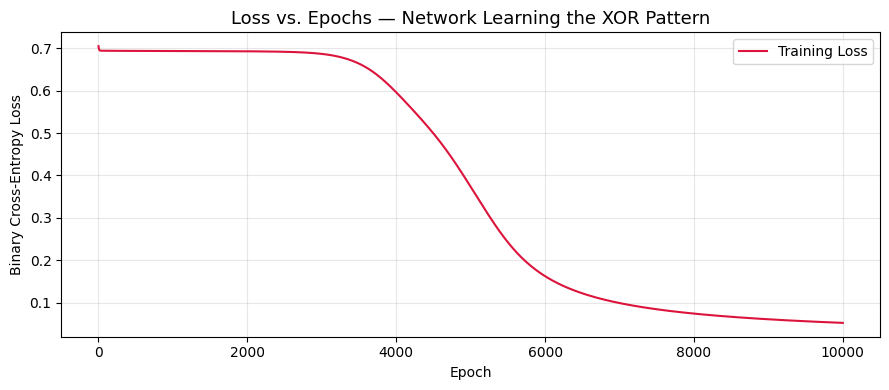

Initial Loss: 0.7046
Final Loss:   0.0529
Loss reduced by: 92.5%


In [17]:
plt.figure(figsize=(9, 4))
plt.plot(nn.loss_history, color='crimson', linewidth=1.5, label='Training Loss')
plt.title("Loss vs. Epochs — Network Learning the XOR Pattern", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial Loss: {nn.loss_history[0]:.4f}")
print(f"Final Loss:   {nn.loss_history[-1]:.4f}")
print(f"Loss reduced by: {(1 - nn.loss_history[-1]/nn.loss_history[0])*100:.1f}%")

##  7: Evaluate Predictions

In [18]:
# Get final predictions
predictions = nn.predict(X)
probabilities = nn.forward(X)

print("Final Predictions on XOR Dataset:")
print("-" * 50)
print(f"{'Input':^12} | {'True':^8} | {'Prob':^10} | {'Predicted':^10} | {'Correct?':^8}")
print("-" * 50)

all_correct = True
for i in range(len(X)):
    correct = "✅" if predictions[i][0] == y[i][0] else "❌"
    if predictions[i][0] != y[i][0]:
        all_correct = False
    print(f"{str(X[i]):^12} | {y[i][0]:^8} | {probabilities[i][0]:^10.4f} | {predictions[i][0]:^10} | {correct:^8}")

print("-" * 50)
accuracy = np.mean(predictions == y) * 100
print(f"\nAccuracy: {accuracy:.1f}%")
if all_correct:
    print("🎉 The MLP has successfully learned the XOR function!")

Final Predictions on XOR Dataset:
--------------------------------------------------
   Input     |   True   |    Prob    | Predicted  | Correct?
--------------------------------------------------
   [0 0]     |    0     |   0.0562   |     0      |    ✅    
   [0 1]     |    1     |   0.9507   |     1      |    ✅    
   [1 0]     |    1     |   0.9506   |     1      |    ✅    
   [1 1]     |    0     |   0.0512   |     0      |    ✅    
--------------------------------------------------

Accuracy: 100.0%
🎉 The MLP has successfully learned the XOR function!


##  8: Visualize Decision Boundary

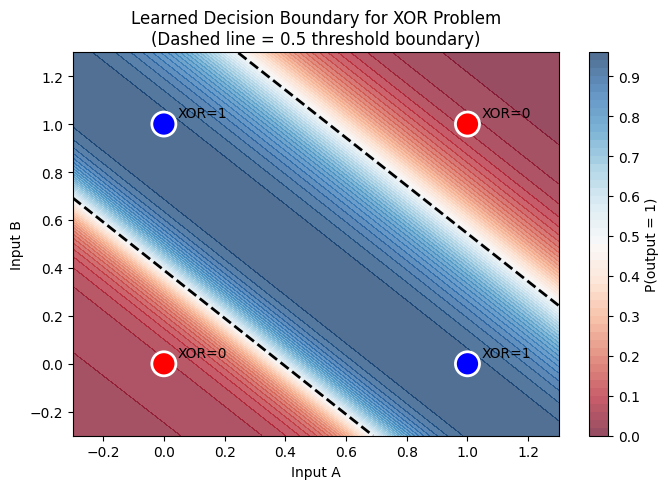

In [19]:
# Create a mesh grid to visualize the learned decision boundary
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 300), np.linspace(-0.3, 1.3, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = nn.forward(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.7)
plt.colorbar(label='P(output = 1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')

colors = ['red' if label == 0 else 'blue' for label in y.flatten()]
plt.scatter(X[:, 0], X[:, 1], c=colors, s=300, edgecolors='white', zorder=5, linewidths=2)

# Annotate points
for i, (xi, yi, li) in enumerate(zip(X[:, 0], X[:, 1], y.flatten())):
    plt.annotate(f"XOR={li}", (xi, yi), textcoords="offset points", xytext=(10, 5), fontsize=10)

plt.title("Learned Decision Boundary for XOR Problem\n(Dashed line = 0.5 threshold boundary)")
plt.xlabel("Input A")
plt.ylabel("Input B")
plt.tight_layout()
plt.show()

##  9: Why a Single Perceptron Fails at XOR

- A single perceptron fails at the XOR (exclusive OR) problem because it can only solve linearly separable problems, meaning it can only split data into two classes using a straight line.
- The XOR function is non-linear; its outputs (0,1,1,0)
create a checkerboard pattern that cannot be separated by a single line
- Let us demonstrate visually why XOR requires a hidden layer.

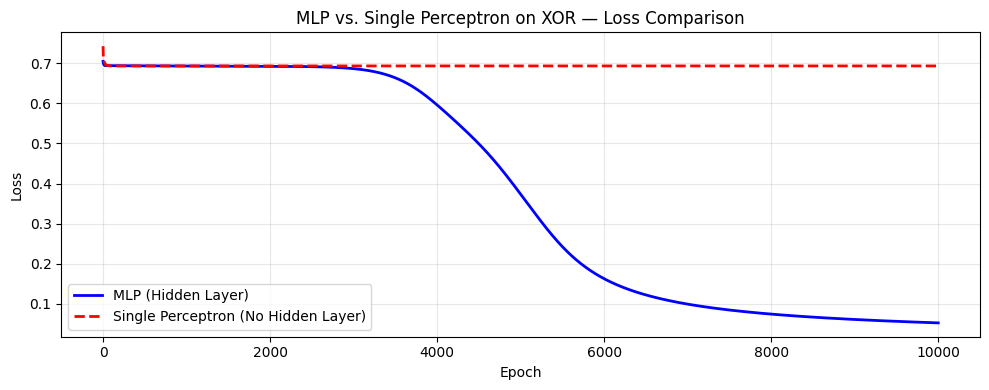

Single Perceptron Accuracy: 50.0%  (cannot solve XOR!)
MLP Accuracy:               100.0%  (solves XOR!)


In [20]:
# Attempt to solve XOR with a single neuron (perceptron) — this will fail!
class SinglePerceptron:
    """A single-layer perceptron — no hidden layers."""
    def __init__(self, lr=0.5):
        self.W = np.random.randn(2, 1) * 0.5
        self.b = np.zeros((1, 1))
        self.lr = lr
        self.loss_history = []

    def forward(self, X):
        return sigmoid(np.dot(X, self.W) + self.b)

    def train(self, X, y, epochs=10000):
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1 - y) * np.log(1 - out + 1e-9))
            self.loss_history.append(loss)
            dZ = out - y
            self.W -= self.lr * np.dot(X.T, dZ) / len(X)
            self.b -= self.lr * np.mean(dZ)

# Train single perceptron
sp = SinglePerceptron(lr=0.5)
sp.train(X, y, epochs=10000)

# Compare losses
plt.figure(figsize=(10, 4))
plt.plot(nn.loss_history, label='MLP (Hidden Layer)', color='blue', linewidth=2)
plt.plot(sp.loss_history, label='Single Perceptron (No Hidden Layer)', color='red', linewidth=2, linestyle='--')
plt.title("MLP vs. Single Perceptron on XOR — Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sp_preds = (sp.forward(X) >= 0.5).astype(int)
print(f"Single Perceptron Accuracy: {np.mean(sp_preds == y)*100:.1f}%  (cannot solve XOR!)")
print(f"MLP Accuracy:               {np.mean(nn.predict(X) == y)*100:.1f}%  (solves XOR!)")

---

##  Summary

| Concept | Key Insight |
|--------|-------------|
| **Forward Propagation** | Data flows input → hidden → output; each layer applies linear transform + activation |
| **Backpropagation** | Gradients flow output → hidden → input using the Chain Rule |
| **Gradient Descent** | Weights updated as: `W = W - lr * dL/dW` |
| **XOR Problem** | Requires at least 1 hidden layer (non-linear decision boundary) |
| **Sigmoid Derivative** | Used in backprop; vanishes at extremes → Vanishing Gradient issue |

---

